In [104]:
import sys
sys.path.append(r'/Users/gabriellebouvier/SIR_Model/src/Particles/Functions.py')

In [105]:
import arviz as az
import numpy as np
from Functions import summary
from Functions import weighted_ess
import matplotlib
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sb
import pickle

In [106]:
# Load data
data_pmcmc = np.load("pmmh_tuning.npz")

pmcmc_list = data_pmcmc['arr0']


In [107]:
print(pmcmc_list['beta'])

[[0.84396108 1.36962305 1.36962305 ... 0.42844372 0.42844372 0.42844372]
 [0.33725456 0.33725456 0.33725456 ... 0.4468113  0.42532726 0.42532726]
 [0.89879116 0.89879116 1.11404596 ... 0.39866161 0.39866161 0.39866161]
 [0.42707298 0.42707298 0.42707298 ... 0.44310576 0.44310576 0.44310576]]


In [108]:
# Posterior distribution arrays
pmcmc_beta = np.array(pmcmc_list['beta'])
pmcmc_gamma = np.array(pmcmc_list['gamma'])

# Summary results

In [109]:
pmcmc_summary = summary('Beta', 'Gamma', pmcmc_beta, pmcmc_gamma, 4)

,Parameter,Mean,Bias,Variance,Std,eti95_lb,eti95_ub,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,rhat,mcse_mean,mcse_std
0,Beta,0.4695,-0.0195,0.0022,0.0474,0.4196,0.5256,0.4139,0.5169,1504.7440,1197.2378,1.0033,0.0021,0.0115
1,Gamma,0.0776,0.0024,0.0060,0.0777,0.0480,0.1110,0.0426,0.1023,1842.8788,1165.7345,1.0033,0.0037,0.0521


In [110]:
exx = pmcmc_0_beta.reshape(1,-1)

print(az.ess(pmcmc_beta, method='tail', prob=.05))

1197.23779782346


In [111]:
beta_dataset = az.convert_to_datatree(pmcmc_beta, group='posterior', )

In [112]:
print(az.summary(beta_dataset))

    mean    sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
x  0.469  0.05     0.42     0.53     1504     1629  1.00    0.0021   0.011


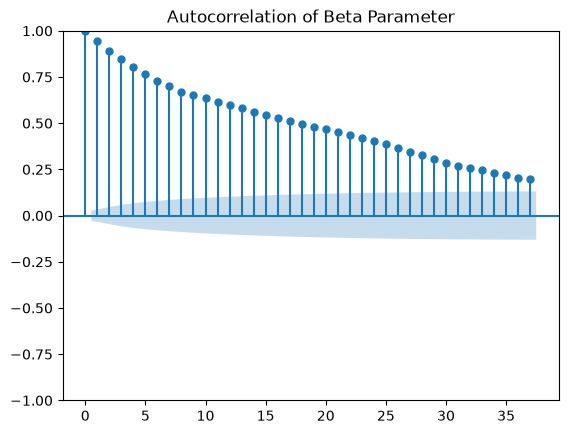

In [113]:
plot_acf(pmcmc_beta[0])
plt.title('Autocorrelation of Beta Parameter')
plt.show()

In [114]:
hdi_beta = az.hdi(pmcmc_beta.flatten())
hdi_gamma = az.hdi(pmcmc_gamma.flatten())


In [115]:
beta_mean = az.mean(pmcmc_beta, round_to=4)
gamma_mean = az.mean(pmcmc_gamma, round_to=4)

print(beta_mean)

0.4695


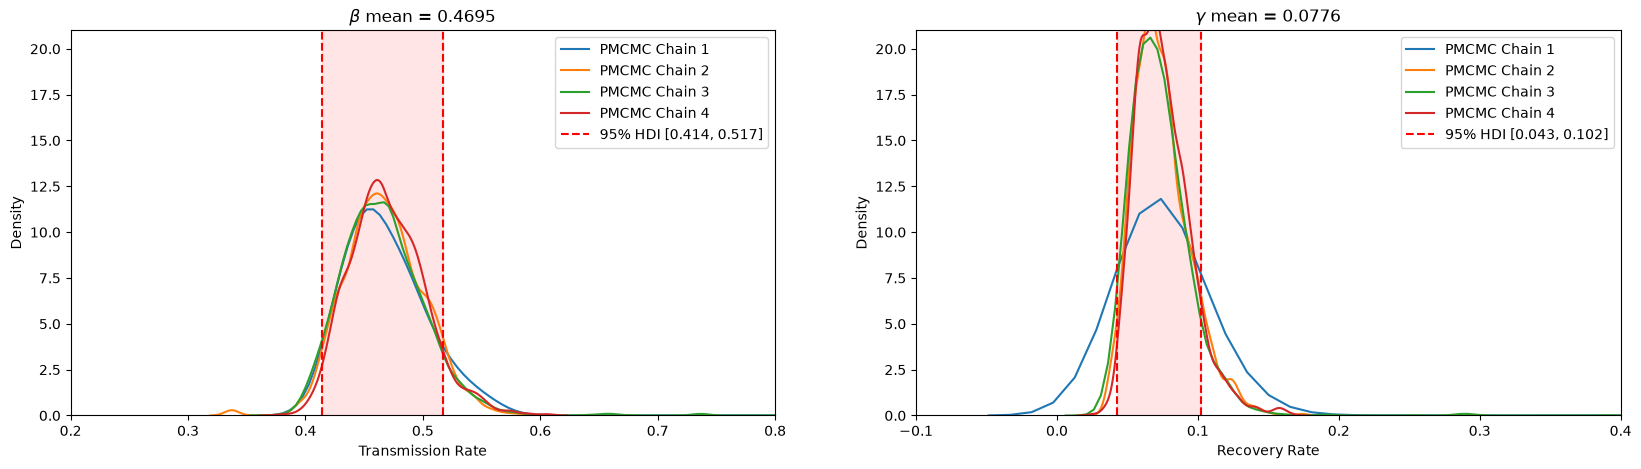

In [116]:

fig, axes = plt.subplots(1,2)
sb.kdeplot(pmcmc_beta[0], ax=axes[0], label = 'PMCMC Chain 1').set_title(rf'$\beta$ mean = {beta_mean}')
sb.kdeplot(pmcmc_gamma[0], ax=axes[1], label = 'PMCMC Chain 1').set_title(rf'$\gamma$ mean = {gamma_mean}')
sb.kdeplot(pmcmc_beta[1], ax=axes[0], label = 'PMCMC Chain 2')
sb.kdeplot(pmcmc_gamma[1], ax=axes[1], label = 'PMCMC Chain 2')
sb.kdeplot(pmcmc_beta[2], ax=axes[0], label = 'PMCMC Chain 3')
sb.kdeplot(pmcmc_gamma[2], ax=axes[1], label = 'PMCMC Chain 3')
sb.kdeplot(pmcmc_beta[3], ax=axes[0], label = 'PMCMC Chain 4')
sb.kdeplot(pmcmc_gamma[3], ax=axes[1], label = 'PMCMC Chain 4')
#axes[0].axvline(x = 0.4438, color='black')
#axes[0].hlines(y = 0.5, xmin = 0.3926, xmax = 0.4896, color='black')
#axes[1].axvline(x = 0.1071, color='black')
#axes[1].hlines(y = 0.5, xmin = 0.0646, xmax = 0.1521, color='black')
axes[0].axvspan(hdi_beta[0], hdi_beta[1], alpha=0.1, color='red')
axes[0].axvline(hdi_beta[0], color='red', linestyle='--', label = f'95% HDI [{hdi_beta[0]:.3f}, {hdi_beta[1]:.3f}]')
axes[0].axvline(hdi_beta[1], color='red', linestyle='--')
axes[1].axvspan(hdi_gamma[0], hdi_gamma[1], alpha=0.1, color='red')
axes[1].axvline(hdi_gamma[0], color='red', linestyle='--', label = f'95% HDI [{hdi_gamma[0]:.3f}, {hdi_gamma[1]:.3f}]')
axes[1].axvline(hdi_gamma[1], color='red', linestyle='--')
axes[0].legend()
axes[1].legend()
axes[0].set_xlabel('Transmission Rate')
axes[1].set_xlabel('Recovery Rate')
axes[0].set_xlim(0.2,0.8)
axes[1].set_xlim(-.1,0.4)
axes[0].set_ylim(0,21)
axes[1].set_ylim(0,21)
fig.set_figheight(5)
fig.set_figwidth(20)

In [117]:
print(dir(pmcmc_0_beta))

['T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__buffer__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dir__', '__divmod__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imatmul__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lshift__', '__lt__', '__matmul__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__'